# **1- Overview :**
### **in this project we will implement the below paper**

https://www.researchgate.net/publication/362504981_Brain_Tumor_Detection_using_MRI_Images_and_Convolutional_Neural_Network

> **Abstract** : A brain tumor is the cause of abnormal growth of
cells in the brain. Magnetic resonance imaging (MRI) is the most
practical method for detecting brain tumors. Through these
MRIs, doctors analyze and identify abnormal tissue growth and
can confirm whether the brain is affected by a tumor or not.
Today, with the emergence of artificial intelligence techniques,
the detection of brain tumors is done by applying the techniques
and algorithms of machine learning and deep learning. The
advantages of the application of these algorithms are the quick
prediction of brain tumors, fewer errors, and greater precision,
which help in decision-making and in choosing the most
appropriate treatment for patients. In the proposed work, a
convolution neural network (CNN) is applied with the aim of
detecting the presence of a brain tumor and its performance is
analyzed. The main purpose of this article is to adopt the
approach of convolutional neural networks as a machine learning
technique to perform brain tumor detection and classification.
Based on training and testing results, the pre-trained
architecture model reaches 96% in precision and classification
accuracy rates. For the given dataset, CNN proves to be the
better technique for predicting the presence of brain tumors.

# **2- Setup**

### Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

#deep learning and computer vision
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

### Constants And Parameters

In [ ]:
DATASET_PATH = "/content/brain_tumor_dataset/Brain_Tumor_Detection"

#Data Parameter
CLASS_LABELS = {"yes": 1, "no": 0}
IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3

#CNN Network HyperParameters

# **3- Load Data**

### Download Data From Kaggle And Unzip ( https://www.kaggle.com/datasets/abhranta/brain-tumor-detection-mri/code)

In [ ]:
!curl -L -o  brain-tumor-detection-mri.zip https://www.kaggle.com/api/v1/datasets/download/abhranta/brain-tumor-detection-mri

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 64.2M  100 64.2M    0     0  12.4M      0  0:00:05  0:00:05 --:--:-- 14.1M


In [ ]:
!unzip /content/brain-tumor-detection-mri.zip -d brain_tumor_dataset

Archive:  /content/brain-tumor-detection-mri.zip
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No12.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No13.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No14.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No15.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No17.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No18.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/No19.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/no0.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/no1.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/no10.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/no100.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/no1000.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detection/no/no1001.jpg  
  inflating: brain_tumor_dataset/Brain_Tumor_Detect

### Load Images (Yes / No From DATASET Path)

In [ ]:
data = []
labels = []

for label, value in CLASS_LABELS.items():
    data_folder = os.path.join(DATASET_PATH, label)

    for filename in os.listdir(data_folder):

        img_path = os.path.join(data_folder, filename)

        #read image
        img = cv2.imread(img_path)
        #resize
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        #normalize image
        img = img / 255.0

        data.append(img)
        labels.append(value)


data = np.array(data, dtype=np.float32)
labels = np.array(labels, dtype=np.int32)

In [ ]:
print("Number of MRI Images : ",len(data))

Number of MRI Images :  3000


### Show sample of images

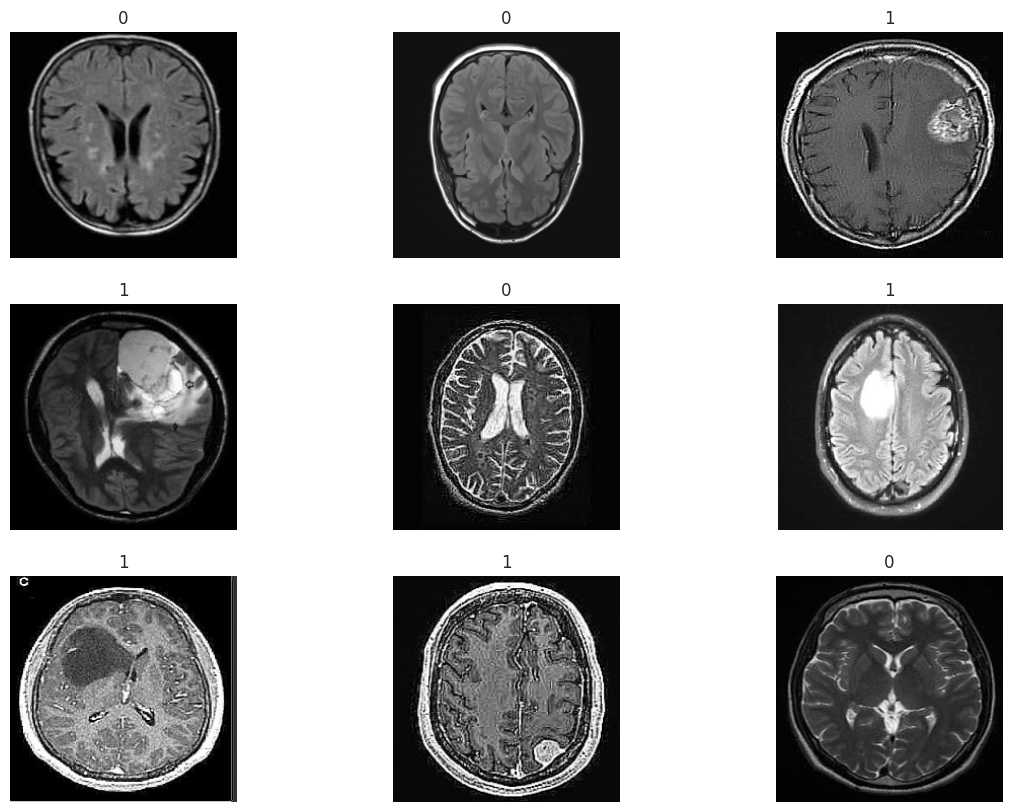

In [ ]:
sample_indicies = np.random.randint(0,3000,9)


fig,axes = plt.subplots(nrows=3,ncols=3,figsize=(14,10))
counter= 0
for row in range(3) :
   for col in range(3):
      axes[row][col].grid(False)
      axes[row][col].axis("off")
      axes[row][col].imshow(data[sample_indicies[counter]])
      axes[row][col].set_title(labels[sample_indicies[counter]])
      counter +=1


# **4- Prepare Data For Traning Model**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#dataset shapes
print(f"training data : {X_train.shape}, training labels : {y_train.shape}")
print(f"validation data : {X_val.shape}, validation labels : {y_val.shape}")
print(f"testing data : {X_test.shape}, testing labels : {y_test.shape}")

training data : (2400, 224, 224, 3), training labels : (2400,)
validation data : (300, 224, 224, 3), validation labels : (300,)
testing data : (300, 224, 224, 3), testing labels : (300,)


# **5- Build CNN Model (with Keras)**

### Build Model

In [ ]:
model = Sequential()

# conv Layers
model.add(Conv2D(20, (4, 4), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(20, (4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(20, (2, 2), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

#flat and dense layers
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))  #output layer ===> two class [0,1] == [yes, no]


model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 221, 221, 20)        │             980 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 110, 110, 20)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 110, 110, 20)        │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 107, 107, 20)        │           6,420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 53, 53, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 53, 53, 20)          │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 20)          │           1,620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 26, 26, 20)          │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 13520)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1024)                │      13,845,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,552,174 (55.51 MB)

 Trainable params: 14,552,054 (55.51 MB)

 Non-trainable params: 120 (480.00 B)

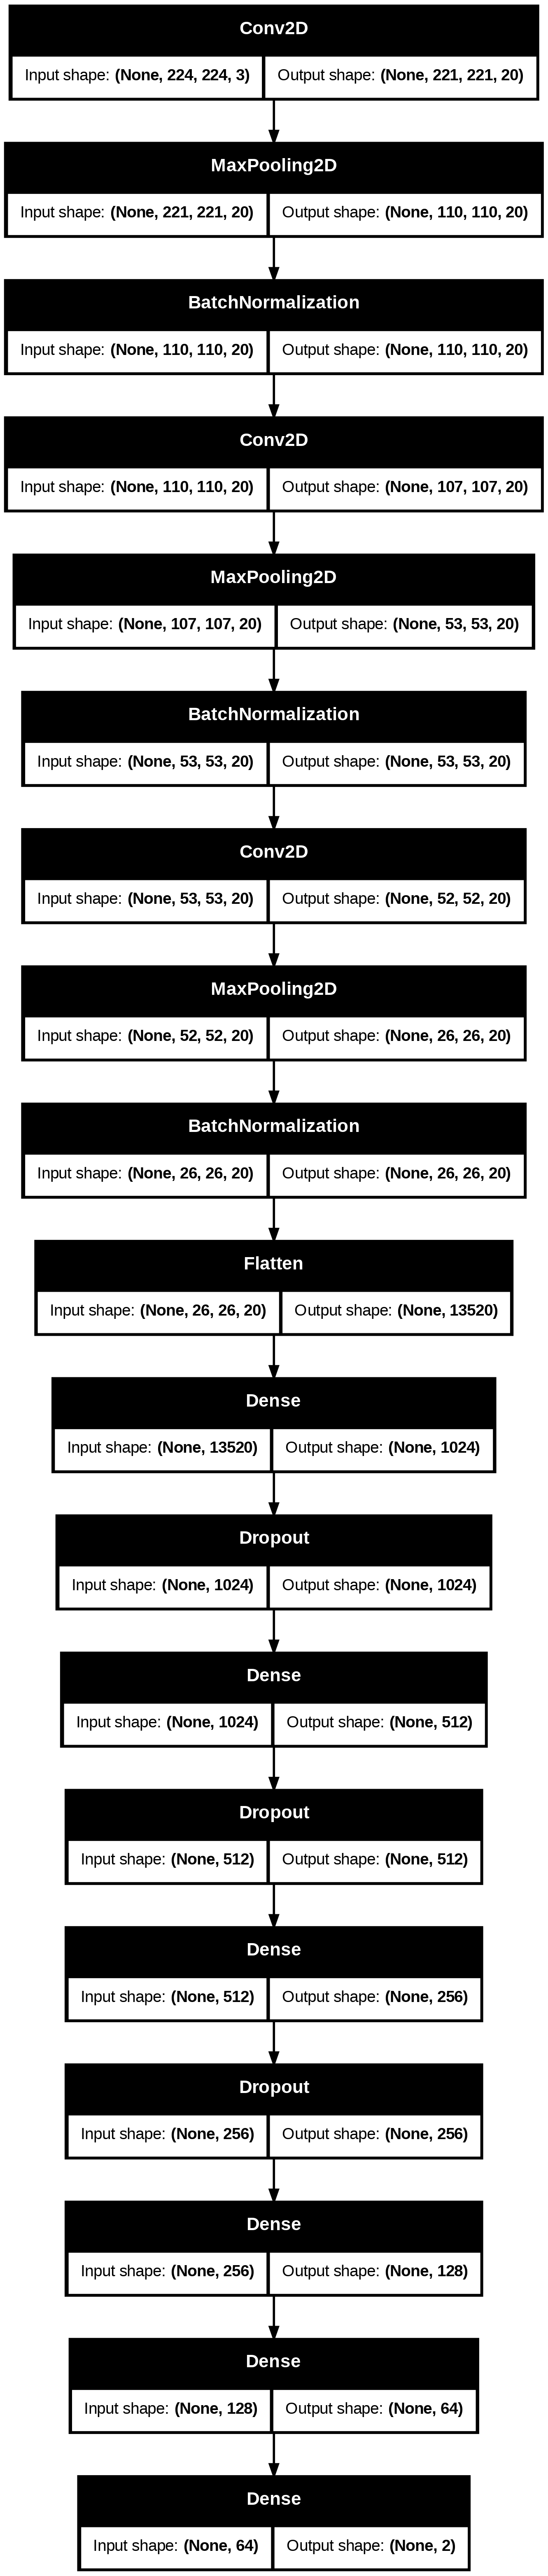

In [ ]:
keras.utils.plot_model(model,show_shapes=True)

### Train Model

In [ ]:
#train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val,y_val))


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.6025 - loss: 1.2935 - val_accuracy: 0.4700 - val_loss: 0.7358
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.6990 - loss: 0.6590 - val_accuracy: 0.7467 - val_loss: 0.5747
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7672 - loss: 0.5030 - val_accuracy: 0.6800 - val_loss: 0.5482
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8707 - loss: 0.3186 - val_accuracy: 0.7533 - val_loss: 0.4299
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9234 - loss: 0.2126 - val_accuracy: 0.9433 - val_loss: 0.1937
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9650 - loss: 0.1157 - val_accuracy: 0.9667 - val_loss: 0.1755
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9787 - loss: 0.0665 - val_accuracy: 0.9667 - val_loss: 0.1181
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9893 - loss: 0.0317 - val_accuracy: 0.9600 - 

# **6- Model Evaluation**

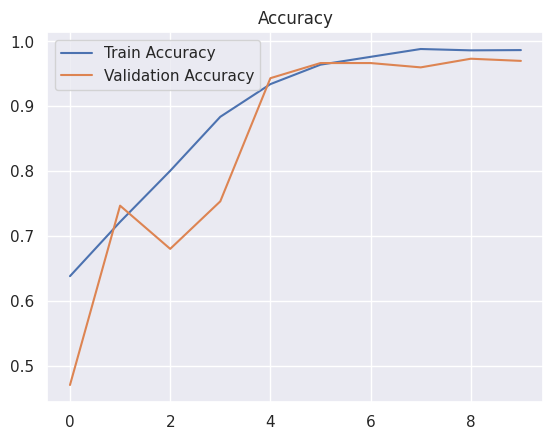

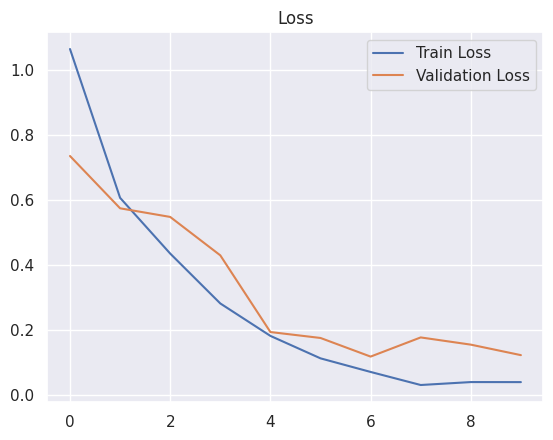

In [ ]:
#plot traning acc
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

#plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()


In [ ]:


test_loss, test_accuracy = model.evaluate(X_test,y_test)
print(f"test Accuracy: {test_accuracy * 100:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9811 - loss: 0.0695
test Accuracy: 98.33%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


In [ ]:
pd.DataFrame(classification_report(y_true, y_pred_classes,output_dict=True)).T

,precision,recall,f1-score,support
0,0.993007,0.972603,0.982699,146.000000
1,0.974522,0.993506,0.983923,154.000000
accuracy,0.983333,0.983333,0.983333,0.983333
macro avg,0.983765,0.983055,0.983311,300.000000
weighted avg,0.983518,0.983333,0.983327,300.000000


### Confusion Matrix

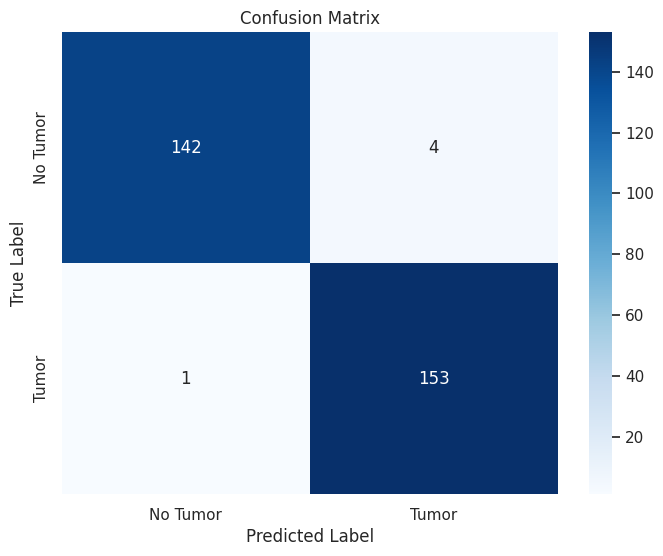

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

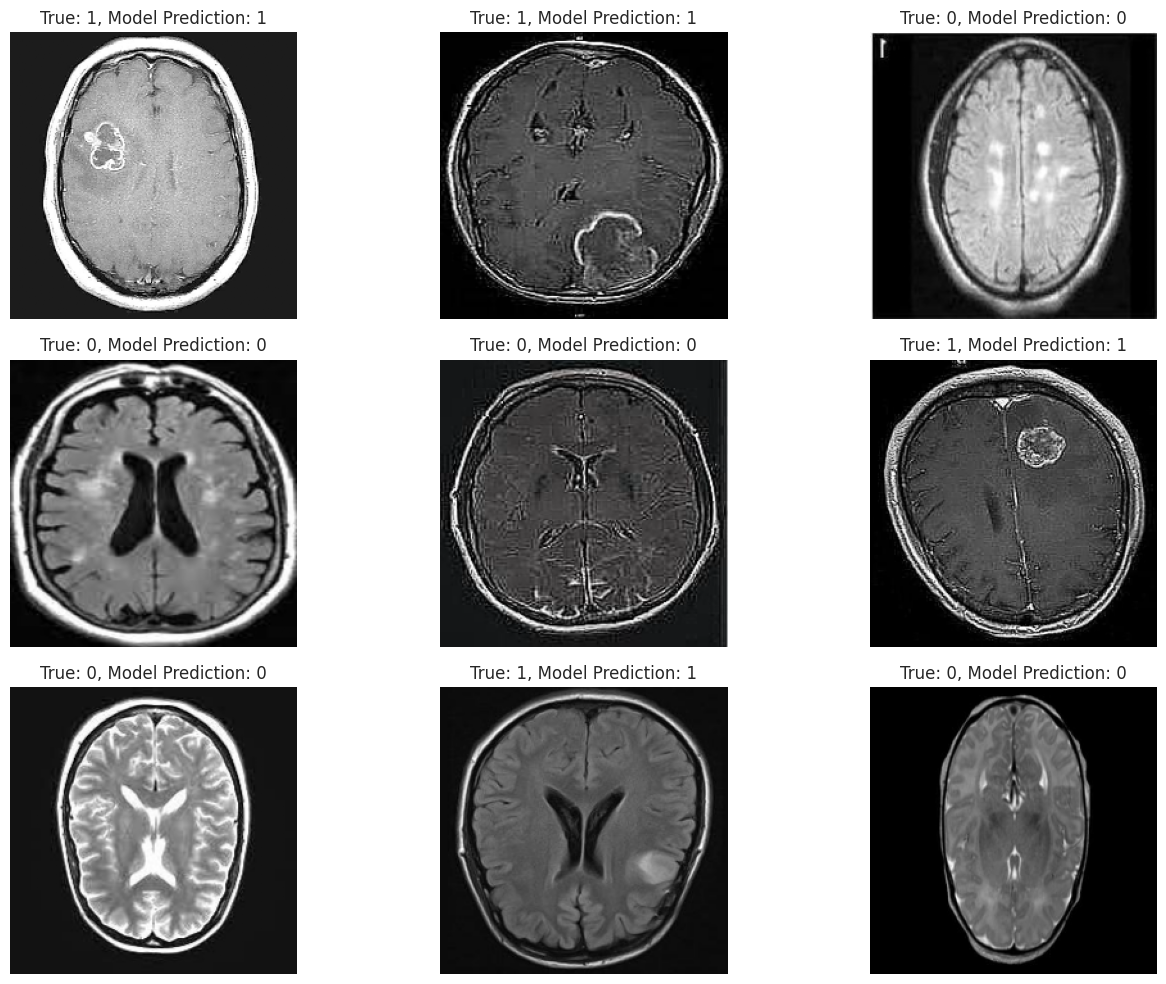

In [ ]:

sample_indicies = np.random.randint(0, len(X_test),9  )

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indicies):
    axes[i].imshow(X_test[idx])
    axes[i].set_title(f'True: {y_test[idx]}, Model Prediction: {y_pred_classes[idx]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()